In [2]:
# --- Cell: The Model Showdown Arena ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Split the raw data FIRST (Never balance before splitting to avoid data leakage!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the data (Crucial for SVM and Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 3. Define the Imbalance Techniques
# We use RandomOverSampler as our baseline "noise" duplication technique
samplers = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'Random_Oversampling': RandomOverSampler(random_state=42) 
}

# 4. Define the Classification Algorithms
# probability=True is required for SVM to calculate the AUC score
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42), 
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 5. The Engine Room Loop
results = []
print("Starting the Model Showdown... Please wait while all models train.\n")

for sampler_name, sampler in samplers.items():
    print(f"Applying {sampler_name}...")
    # Balance the training data
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    
    for model_name, model in models.items():
        # Train the model
        model.fit(X_resampled, y_resampled)
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate scores
        results.append({
            'Balancing Technique': sampler_name,
            'Algorithm': model_name,
            'Accuracy': round(accuracy_score(y_test, y_pred), 4),
            'Precision': round(precision_score(y_test, y_pred), 4),
            'Recall': round(recall_score(y_test, y_pred), 4),
            'F1-Score': round(f1_score(y_test, y_pred), 4),
            'AUC': round(roc_auc_score(y_test, y_pred_proba), 4)
        })

# 6. Create the Ultimate Leaderboard
leaderboard = pd.DataFrame(results)

# Sort by the highest AUC (The best overall metric for imbalanced data)
leaderboard = leaderboard.sort_values(by='AUC', ascending=False).reset_index(drop=True)

print("\n--- EXPERIMENT COMPLETE ---")
display(leaderboard)

NameError: name 'X' is not defined

In [3]:
import pandas as pd

# 1. Load the clean data
df = pd.read_csv('../data/cleaned_gym_data.csv')

# 2. Separate Features (X) and Target (y)
X = df.drop('churn', axis=1)
y = df['churn']

print(f"Data loaded! Ready for modeling. Shape: {df.shape}")

Data loaded! Ready for modeling. Shape: (4000, 14)


In [4]:
# --- Cell 4: Handling Imbalanced Data with SMOTE ---
from imblearn.over_sampling import SMOTE

# 1. Separate the Features (X) from the Target (y)
# X contains all the gym habits, y contains only the final Churn result
X = df.drop('churn', axis=1)
y = df['churn']

# Check the exact imbalance before SMOTE
print("--- BEFORE SMOTE ---")
print(y.value_counts())

# 2. Initialize and Apply SMOTE
# random_state=42 ensures that if your teammates run this, they get the exact same synthetic data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 3. Verify the Magic
print("\n--- AFTER SMOTE ---")
print(y_resampled.value_counts())
print(f"\nNew Expanded Dataset Shape: {X_resampled.shape[0]} rows!")

--- BEFORE SMOTE ---
churn
0    2939
1    1061
Name: count, dtype: int64

--- AFTER SMOTE ---
churn
0    2939
1    2939
Name: count, dtype: int64

New Expanded Dataset Shape: 5878 rows!


In [5]:
!pip install xgboost

Running 5-Fold Cross-Validation for AUC...


C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:25:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:25:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:25:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:25:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not use

Cross-Validation AUC: 0.9927 (+/- 0.0054)

Training XGBoost on the 80% split...
--- XGBoost Final Performance Metrics ---
Accuracy:  0.9575
Precision: 0.9552 (When it predicts churn, how often is it right?)
Recall:    0.9585 (Out of all actual churners, how many did it catch?)
F1-Score:  0.9569
Test AUC:  0.9923


C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:25:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


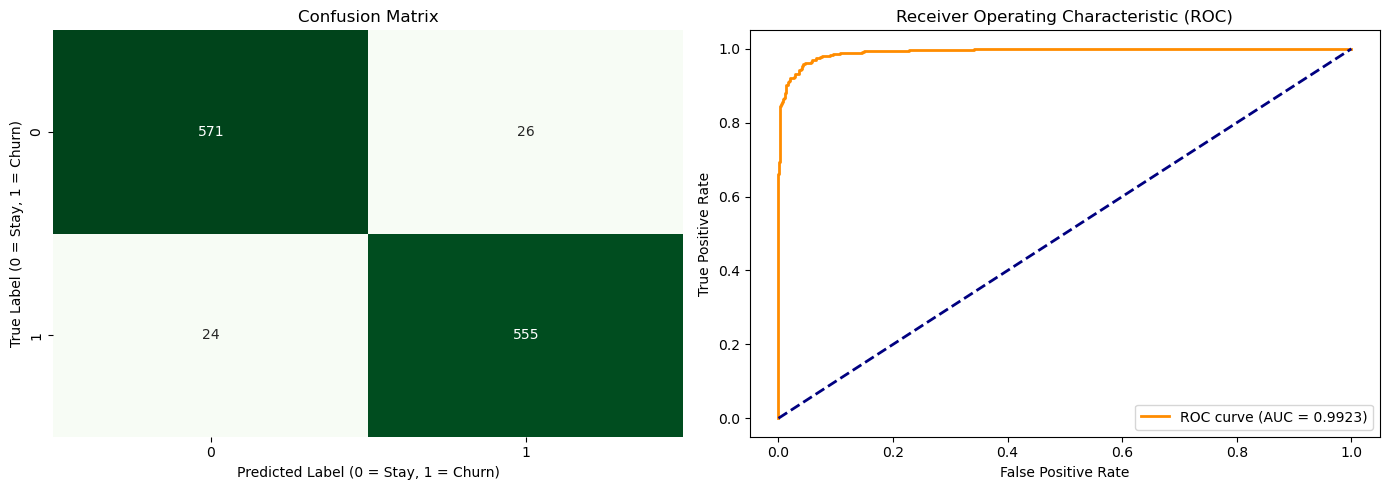

In [6]:
# --- Cell 5: Advanced XGBoost with Comprehensive Metrics ---
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. The 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 2. Initialize the Algorithm
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 3. Cross-Validation AUC (The Ultimate Proof of Stability)
print("Running 5-Fold Cross-Validation for AUC...")
# This cuts the data into 5 pieces, trains on 4, tests on 1, and rotates. 
cv_auc_scores = cross_val_score(xgb_model, X_resampled, y_resampled, cv=5, scoring='roc_auc')
print(f"Cross-Validation AUC: {cv_auc_scores.mean():.4f} (+/- {cv_auc_scores.std():.4f})\n")

# 4. Turn on the Heat (Train the model)
print("Training XGBoost on the 80% split...")
xgb_model.fit(X_train, y_train)

# 5. Make Predictions (Both rigid classes and probabilities)
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1] # We need probabilities for ROC/AUC

# 6. Calculate All Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

# 7. Print the Report Card
print("--- XGBoost Final Performance Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (When it predicts churn, how often is it right?)")
print(f"Recall:    {recall:.4f} (Out of all actual churners, how many did it catch?)")
print(f"F1-Score:  {f1:.4f}")
print(f"Test AUC:  {auc:.4f}")

# 8. Visualizing the Results (Confusion Matrix & ROC Curve)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label (0 = Stay, 1 = Churn)')
axes[0].set_ylabel('True Label (0 = Stay, 1 = Churn)')

# Plot B: ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The 50/50 guessing line
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

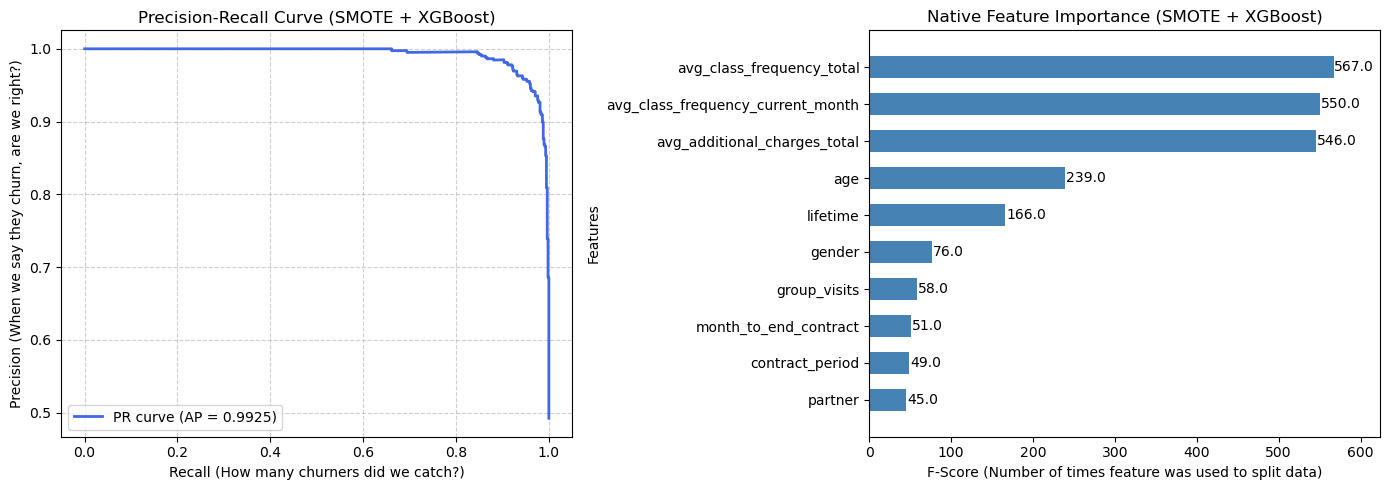

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graph 1: Precision-Recall Curve (SMOTE + XGBoost) ---
# We use y_pred_proba from your earlier SMOTE code block
precision_smote, recall_smote, _ = precision_recall_curve(y_test, y_pred_proba)
ap_score_smote = average_precision_score(y_test, y_pred_proba)

axes[0].plot(recall_smote, precision_smote, color='royalblue', lw=2, label=f'PR curve (AP = {ap_score_smote:.4f})')
axes[0].set_title('Precision-Recall Curve (SMOTE + XGBoost)')
axes[0].set_xlabel('Recall (How many churners did we catch?)')
axes[0].set_ylabel('Precision (When we say they churn, are we right?)')
axes[0].legend(loc="lower left")
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Graph 2: XGBoost Native Feature Importance (SMOTE) ---
# We use xgb_model from your earlier SMOTE code block
plot_importance(xgb_model, ax=axes[1], max_num_features=10, 
                height=0.6, color='steelblue', title='Native Feature Importance (SMOTE + XGBoost)',
                xlabel='F-Score (Number of times feature was used to split data)')
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [7]:
!pip install shap

Calculating SHAP values... this might take a few moments.


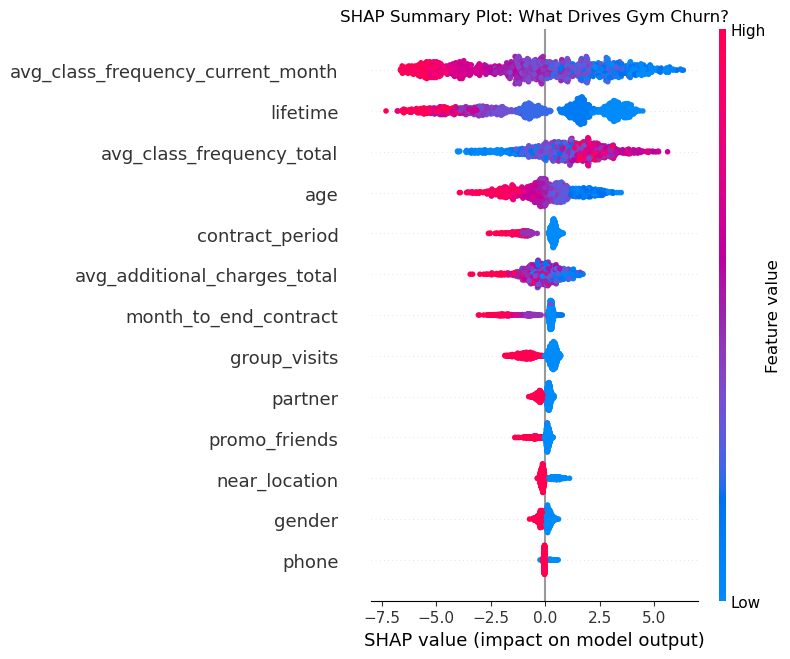

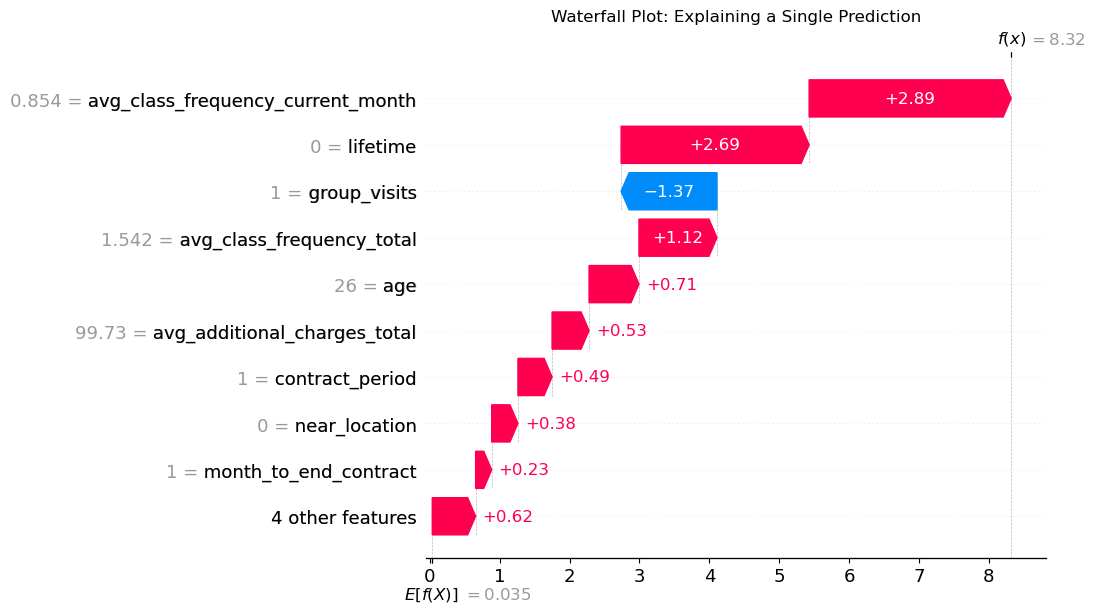

In [8]:
# --- Cell 6: Explainable AI (XAI) with SHAP ---
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
# We use TreeExplainer because XGBoost is a tree-based model
print("Calculating SHAP values... this might take a few moments.")
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculate the exact impact of every feature for the test data
shap_values = explainer.shap_values(X_test)

# 3. Plot A: The Summary Plot (The Big Picture)
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: What Drives Gym Churn?")
# This generates a beautiful, color-coded dot plot
shap.summary_plot(shap_values, X_test, show=False) 
plt.show()

# 4. Plot B: The Waterfall Plot (A Single Gym Member's Brain)
# Let's look at the very first person in our test set (index 0) to see exactly why the model predicted their outcome
plt.figure(figsize=(8, 5))
shap_explainer_obj = shap.Explainer(xgb_model)
shap_values_obj = shap_explainer_obj(X_test)

plt.title("Waterfall Plot: Explaining a Single Prediction")
shap.plots.waterfall(shap_values_obj[0])
plt.show()

1. Applying Random Oversampling...
Data balanced! New training shape: 4720 rows.
2. Training XGBoost...
Training complete!

--- Champion Model: ROS + XGBoost ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       597
           1       0.96      0.96      0.96       579

    accuracy                           0.96      1176
   macro avg       0.96      0.96      0.96      1176
weighted avg       0.96      0.96      0.96      1176

Final Test AUC: 0.9925



C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:25:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


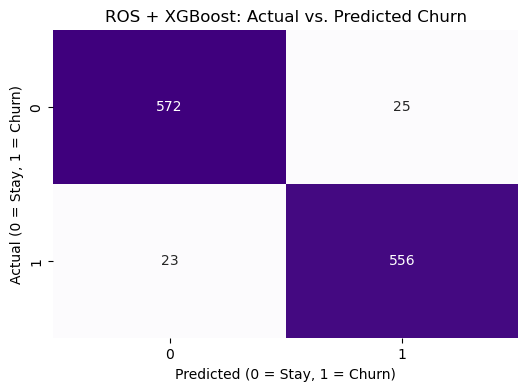

In [9]:
# --- Cell: Training the Champion (Random Oversampling + XGBoost) ---
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Applying Random Oversampling...")
# Initialize and apply Random Oversampling to our training data
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print(f"Data balanced! New training shape: {X_train_ros.shape[0]} rows.")

print("2. Training XGBoost...")
# Initialize and train the algorithm
xgb_ros_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_ros_model.fit(X_train_ros, y_train_ros)
print("Training complete!\n")

# 3. Make Predictions
y_pred_ros = xgb_ros_model.predict(X_test)
y_pred_proba_ros = xgb_ros_model.predict_proba(X_test)[:, 1]

# 4. The Report Card
auc_score = roc_auc_score(y_test, y_pred_proba_ros)
print("--- Champion Model: ROS + XGBoost ---")
print(classification_report(y_test, y_pred_ros))
print(f"Final Test AUC: {auc_score:.4f}\n")

# 5. Visualizing the Accuracy
plt.figure(figsize=(6,4))
# Using a 'Purples' color map to easily distinguish it from our previous SMOTE chart
sns.heatmap(confusion_matrix(y_test, y_pred_ros), annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('ROS + XGBoost: Actual vs. Predicted Churn')
plt.xlabel('Predicted (0 = Stay, 1 = Churn)')
plt.ylabel('Actual (0 = Stay, 1 = Churn)')
plt.show()

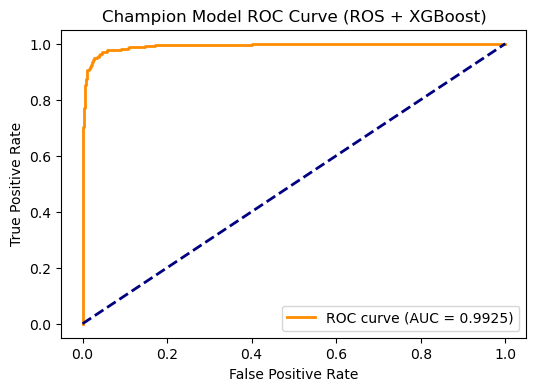

In [10]:
from sklearn.metrics import roc_curve

# Calculate the points for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_ros)

# Plot it
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The 50/50 guessing line
plt.title('Champion Model ROC Curve (ROS + XGBoost)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

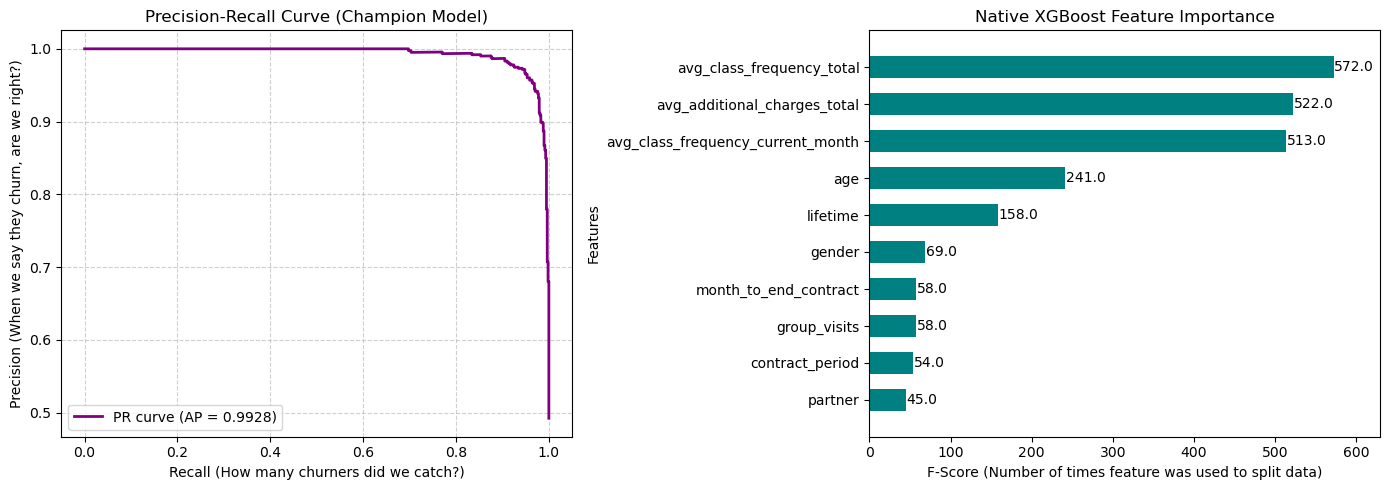

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from xgboost import plot_importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graph 1: Precision-Recall Curve ---
# Calculate precision, recall, and the Average Precision (AP) score
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_ros)
ap_score = average_precision_score(y_test, y_pred_proba_ros)

axes[0].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {ap_score:.4f})')
axes[0].set_title('Precision-Recall Curve (Champion Model)')
axes[0].set_xlabel('Recall (How many churners did we catch?)')
axes[0].set_ylabel('Precision (When we say they churn, are we right?)')
axes[0].legend(loc="lower left")
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Graph 2: XGBoost Native Feature Importance ---
# XGBoost has a built-in plotting function, we just point it to our axis
plot_importance(xgb_ros_model, ax=axes[1], max_num_features=10, 
                height=0.6, color='teal', title='Native XGBoost Feature Importance',
                xlabel='F-Score (Number of times feature was used to split data)')
axes[1].grid(False) # Turn off grid for cleaner look

plt.tight_layout()
plt.show()

Calculating SHAP values for the Champion Model... This will just take a moment.


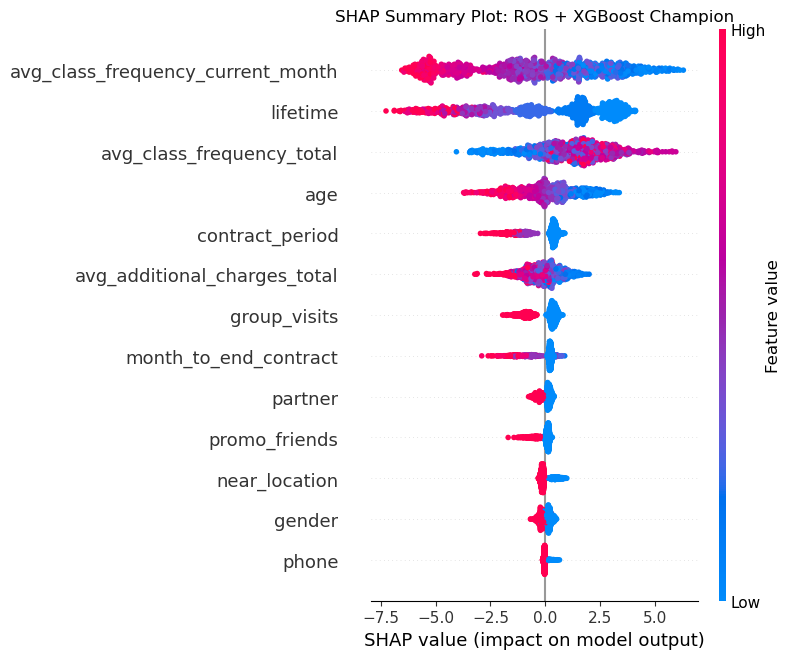

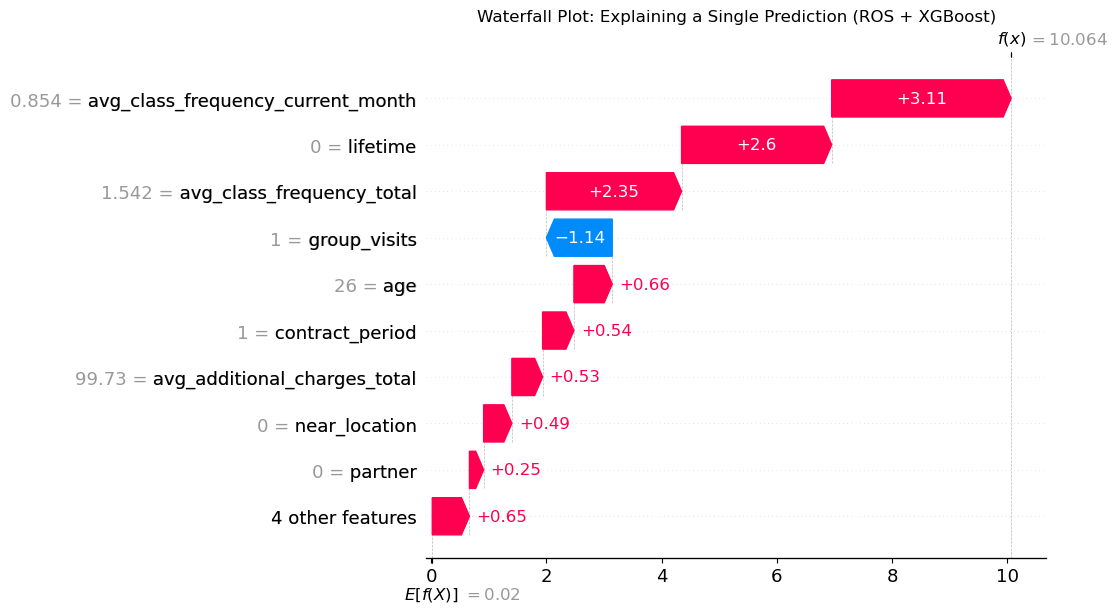

In [13]:
# --- Cell: Explainable AI (SHAP) for the Champion Model (ROS + XGBoost) ---
import shap
import pandas as pd
import matplotlib.pyplot as plt

print("Calculating SHAP values for the Champion Model... This will just take a moment.")

# 1. Reattach column names to X_test so our charts have readable labels
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# 2. Initialize the SHAP Explainer for the ROS model
explainer_ros = shap.TreeExplainer(xgb_ros_model)

# 3. Calculate the exact impact of every feature
shap_values_ros = explainer_ros.shap_values(X_test_df)

# 4. Plot A: The Summary Plot (The Big Picture)
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: ROS + XGBoost Champion")
shap.summary_plot(shap_values_ros, X_test_df, show=False)
plt.show()

# 5. Plot B: The Waterfall Plot (Zooming in on member index 0)
plt.figure(figsize=(8, 5))
# We need the Explainer object specifically formatted for the waterfall plot
shap_explainer_obj_ros = shap.Explainer(xgb_ros_model)
shap_values_obj_ros = shap_explainer_obj_ros(X_test_df)

plt.title("Waterfall Plot: Explaining a Single Prediction (ROS + XGBoost)")
shap.plots.waterfall(shap_values_obj_ros[0])
plt.show()

1. Applying SMOTE & Training Logistic Regression...
--- Baseline Model: SMOTE + Logistic Regression ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       597
           1       0.95      0.95      0.95       579

    accuracy                           0.95      1176
   macro avg       0.95      0.95      0.95      1176
weighted avg       0.95      0.95      0.95      1176



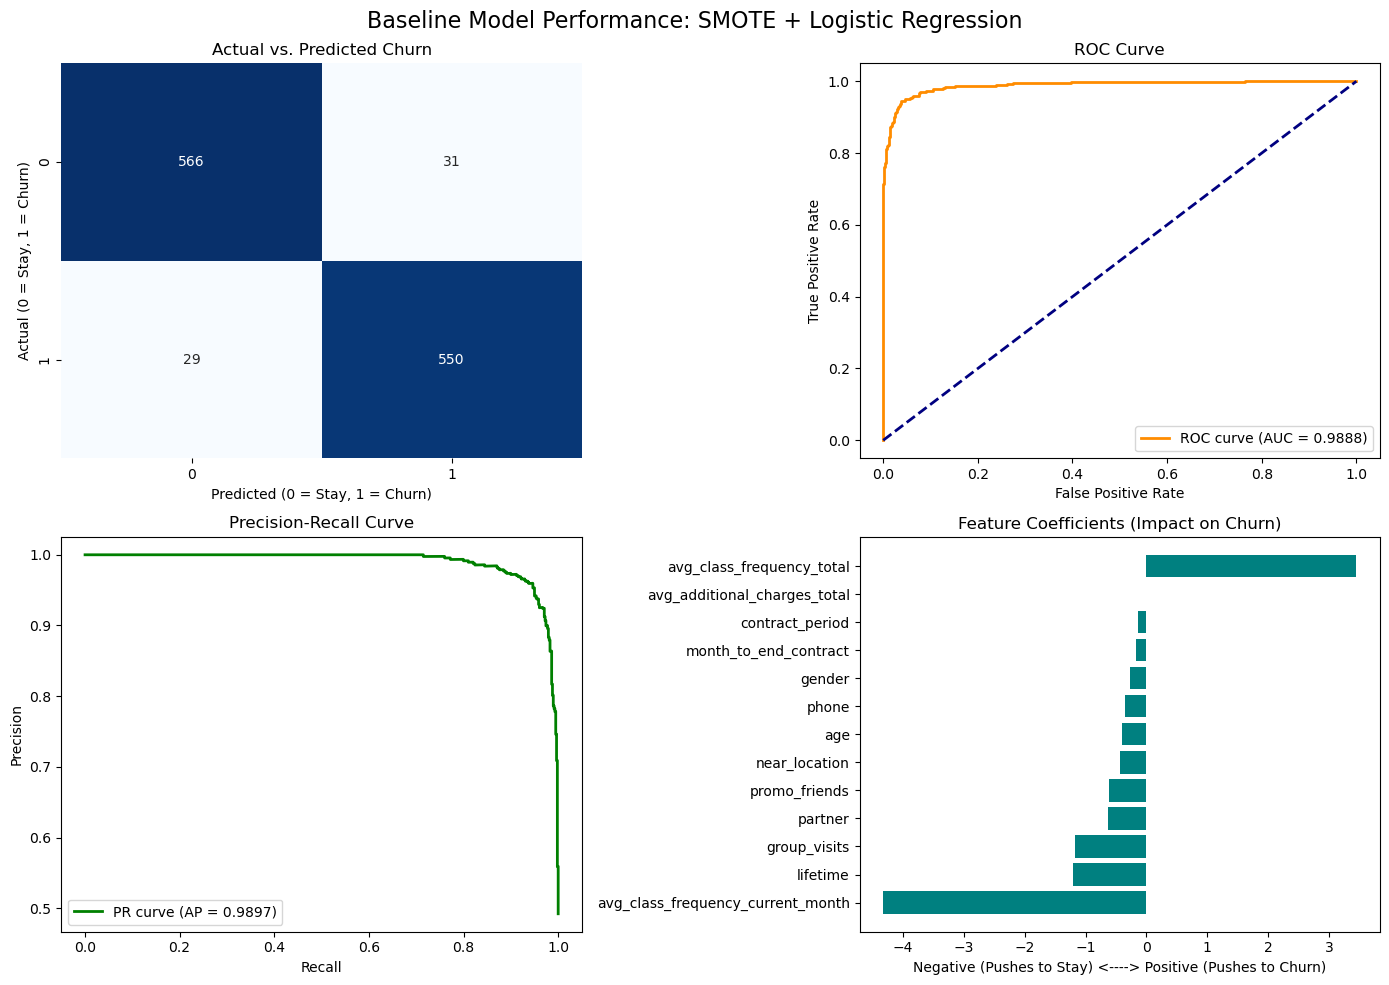

In [14]:
# --- Cell: Training & Visualizing SMOTE + Logistic Regression ---
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("1. Applying SMOTE & Training Logistic Regression...")
# 1. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 2. Train Logistic Regression (requires scaled data, which X_train already is!)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

# 3. Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print("--- Baseline Model: SMOTE + Logistic Regression ---")
print(classification_report(y_test, y_pred_lr))

# 4. Create the 2x2 Visual Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Baseline Model Performance: SMOTE + Logistic Regression', fontsize=16)

# --- Top Left: Confusion Matrix ---
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_title('Actual vs. Predicted Churn')
axes[0, 0].set_xlabel('Predicted (0 = Stay, 1 = Churn)')
axes[0, 0].set_ylabel('Actual (0 = Stay, 1 = Churn)')

# --- Top Right: ROC Curve ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
axes[0, 1].plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_lr:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc="lower right")

# --- Bottom Left: Precision-Recall Curve ---
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
ap_lr = average_precision_score(y_test, y_pred_proba_lr)
axes[1, 0].plot(recall_lr, precision_lr, color='green', lw=2, label=f'PR curve (AP = {ap_lr:.4f})')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend(loc="lower left")

# --- Bottom Right: Feature Coefficients (LR's version of Feature Importance) ---
# Extract coefficients and map them to column names
coefficients = pd.DataFrame({'Feature': X.columns, 'Weight': lr_model.coef_[0]})
coefficients = coefficients.sort_values(by='Weight', ascending=True)

# Plotting the weights
axes[1, 1].barh(coefficients['Feature'], coefficients['Weight'], color='teal')
axes[1, 1].set_title('Feature Coefficients (Impact on Churn)')
axes[1, 1].set_xlabel('Negative (Pushes to Stay) <----> Positive (Pushes to Churn)')

plt.tight_layout()
plt.show()

Calculating SHAP values for Logistic Regression...


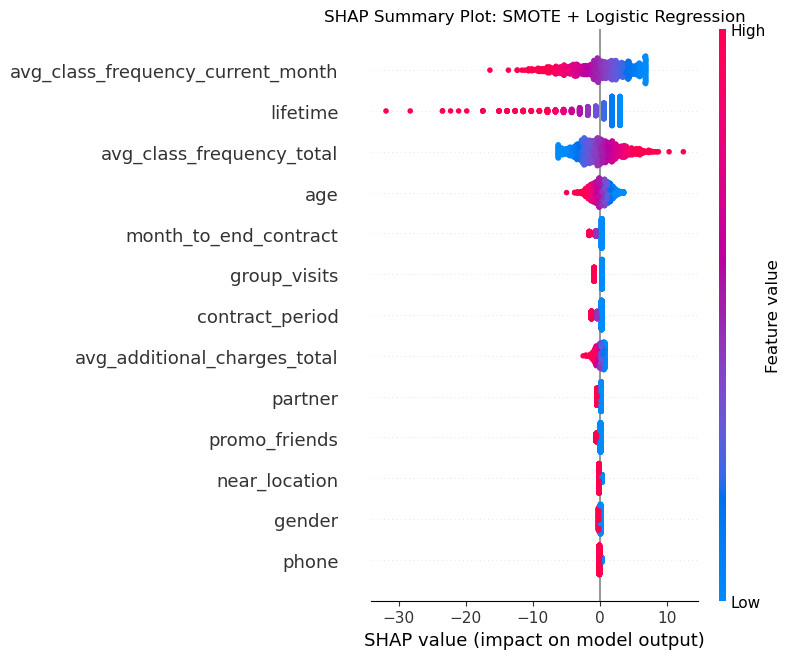

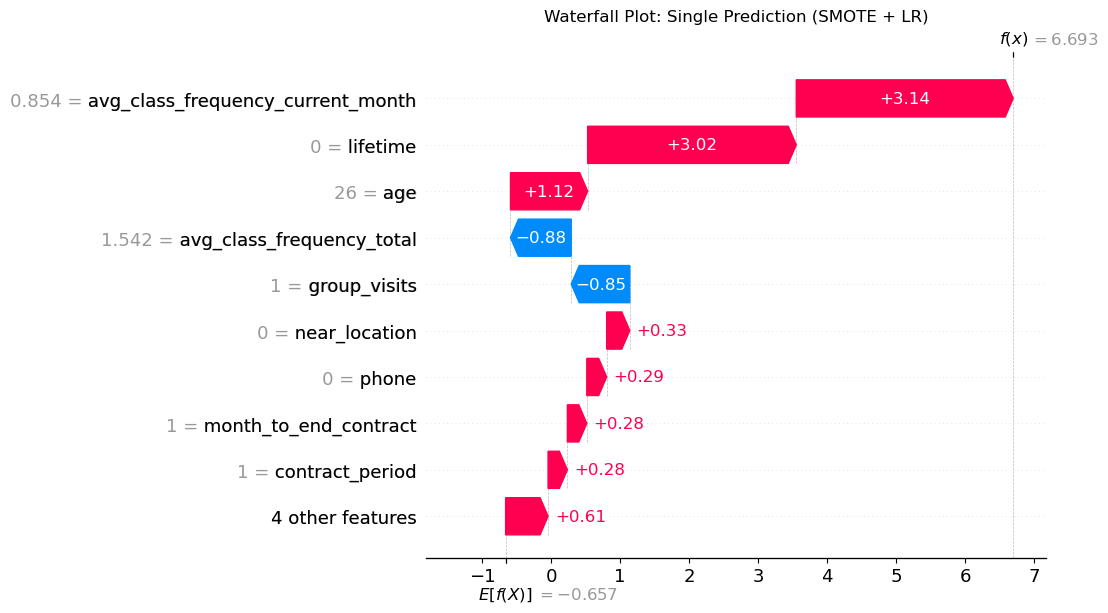

In [15]:
# --- Cell: Explainable AI (SHAP) for SMOTE + Logistic Regression ---
import shap

print("Calculating SHAP values for Logistic Regression...")

# 1. Reattach column names to our arrays so the charts are readable
X_train_smote_df = pd.DataFrame(X_train_smote, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# 2. Initialize the Explainer (SHAP will auto-detect that this is a Linear model)
# We provide the training data so it understands the baseline distributions
explainer_lr = shap.Explainer(lr_model, X_train_smote_df)

# 3. Calculate SHAP values for the test set
shap_values_lr = explainer_lr(X_test_df)

# 4. Plot A: Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: SMOTE + Logistic Regression")
shap.summary_plot(shap_values_lr, X_test_df, show=False)
plt.show()

# 5. Plot B: Waterfall Plot (Looking at member index 0 again)
plt.figure(figsize=(8, 5))
plt.title("Waterfall Plot: Single Prediction (SMOTE + LR)")
shap.plots.waterfall(shap_values_lr[0])
plt.show()

In [16]:
!pip install joblib

In [18]:
# --- THE BULLETPROOF FINAL EXPORT CELL ---
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Create the app folder if it doesn't exist yet
if not os.path.exists('../app'):
    os.makedirs('../app')

print("1. Preparing and scaling fresh data...")
# We explicitly recreate the split and the scaler so Jupyter doesn't forget them!
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

print("2. Training and exporting the Top 3 Models to the /app folder...")

# --- Model 1: Random Oversampling + XGBoost (The Champion) ---
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)
model_1 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_1.fit(X_train_ros, y_train_ros)
joblib.dump(model_1, '../app/model_1_ros_xgb.pkl')
print("   - Champion Model Exported!")

# --- Model 2: SMOTE + XGBoost (Runner-Up) ---
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
model_2 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_2.fit(X_train_smote, y_train_smote)
joblib.dump(model_2, '../app/model_2_smote_xgb.pkl')
print("   - Runner-Up Model Exported!")

# --- Model 3: SMOTE + Logistic Regression (Baseline) ---
model_3 = LogisticRegression(max_iter=1000, random_state=42)
model_3.fit(X_train_smote, y_train_smote)
joblib.dump(model_3, '../app/model_3_smote_lr.pkl')
print("   - Baseline Model Exported!")

# --- Export the Scaler ---
joblib.dump(scaler, '../app/gym_data_scaler.pkl')
print("   - Scaler Exported!")

print("\n🚀 All systems go! Your Engine Room is fully exported.")

1. Preparing and scaling fresh data...
2. Training and exporting the Top 3 Models to the /app folder...
   - Champion Model Exported!


C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:37:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:37:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   - Runner-Up Model Exported!
   - Baseline Model Exported!
   - Scaler Exported!

🚀 All systems go! Your Engine Room is fully exported.
